In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

Il dataset **California Housing** contiene informazioni raccolte durante il censimento degli Stati Uniti del **1990** nello stato della California, dove l'unità di misura minima analizzata non è la singola casa, ma il **gruppo di blocchi censuari** o **zone**, ciascuno dei quali ospita mediamente tra le 600 e le 3.000 persone (si tratta di un insieme di isolati).

L'obiettivo tipico dell'elaborazione di questi dati è predire il valore medio delle case di una zona basandosi sulle sue caratteristiche demografiche e geografiche.

---

### Struttura e Caratteristiche

Il dataset è composto da **20.640 campioni (righe)** e **8 variabili features**, più la variabile target numerica.

Di seguito riportiamo il nome di ciascune feature e il suo significato:

**MedInc**= Reddito medio delle famiglie nella zona (espresso in decine di migliaia di dollari, es. 3.5 = $35.000).

**HouseAge** = Età media degli edifici nella zona.

**AveRooms** = Numero medio di stanze per abitazione.

**AveBedrms** = Numero medio di stanze da letto per abitazione.

**Population** = Popolazione totale residente nel blocco censuario.

**AveOccup** = Numero medio di componenti per nucleo familiare.

**Latitude** = Latitudine geografica del centro della zona.

**Longitude** = Longitudine geografica del centro della zona.

La variabile target invece è
**MedHouseValue** = Valore medio delle case (espresso in centinaia di migliaia di dollari, es. 2.5 = $250.000).


* **Il problema del "Top-Coding":**  la variabile target `MedHouseValue` ha un limite massimo artificiale impostato a `5.00001`. Questo troncamento rappresenta una difficoltà aggiuntiva nella gestione del dataset e nell'accuratezza dei modelli costruiti su di esso.

In [13]:
# 1. Caricamento del dataset completo
california = fetch_california_housing(as_frame=True)
df = california.frame

X = california.data
y = california.target  # Il valore medio della casa



In [14]:

# Suddivisione del dataset in due gruppi: Training set (80%) e Test set (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("dimensioni training set: ",X_train.shape)
print("dimensioni test set: ",X_test.shape)

# Stampiamo i nomi delle features
print("Nomi Features:")
print(list(X.columns))

dimensioni training set:  (16512, 8)
dimensioni test set:  (4128, 8)
Nomi Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [15]:
# Sporcizia
#m,n = X_train.shape
#A = np.c_[np.ones(m),X_train]

In [ ]:
def regressione_gl(X_train,y,tol):
  m,n = X_train.shape
  A = np.c_[np.ones(m),X_train] #concateniamo una colonna di 1 a sinistra
  n = n + 1                     #ora n è il numero di colonne di A
  print("calcolando la SVD...")
  U, S, Vt = np.linalg.svd(A) #il grosso del calcolo sta qui (nella fattorizzazione)
  print("fatto")
  k = np.max(np.where(S>tol))+1
  z = U.T@y
  gamma = np.zeros(n)
  gamma[:k] = z[:k]/S[:k]
  alpha = Vt.T@gamma
  return alpha,k

In [22]:
alpha,k = regressione_gl(X_train,y_train,1e-9)

calcolando la SVD...
fatto


In [ ]:
# Mostriamo il coefficiente (peso) di ciascuna feature sul prezzo finale
for i in range(X_train.shape[1]):
  print(f"{X.columns[i]:11s}  {alpha[i+1]:10.6f}")

MedInc         0.448675
HouseAge       0.009724
AveRooms      -0.123323
AveBedrms      0.783145
Population    -0.000002
AveOccup      -0.003526
Latitude      -0.419792
Longitude     -0.433708


In [19]:
#Predizione del modello sui dati del training set
y_pred_test = X_test@alpha[1:] + alpha[0]

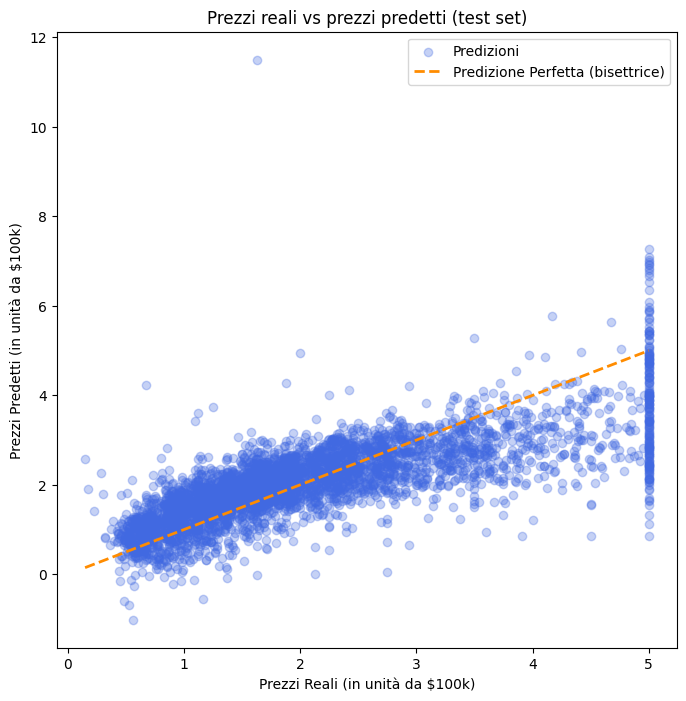

In [20]:
# Grafico di confronto prezzi reali rispetto prezzi predetti dal modello (test set)
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_test, color="royalblue", alpha=0.3, label="Predizioni")
# Retta di perfetta corrispondenza
limiti = [y_test.min(), y_test.max()]
plt.plot(
    limiti,
    limiti,
    color="darkorange",
    linestyle="--",
    linewidth=2,
    label="Predizione Perfetta (bisettrice)",
)
plt.title("Prezzi reali vs prezzi predetti (test set)")
plt.xlabel("Prezzi Reali (in unità da $100k)")
plt.ylabel("Prezzi Predetti (in unità da $100k)")
plt.legend()

In [21]:





# 3. Creazione e addestramento del modello di Regressione Lineare Multipla
modello_multiplo = LinearRegression()
modello_multiplo.fit(X_train, y_train)

# 4. Predizione sui dati di test
y_pred = modello_multiplo.predict(X_test)

# 5. Valutazione del modello
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Performance del Modello Multiplo ---")
print(f"Intercetta (q): {modello_multiplo.intercept_:.4f}")
print(f"Errore Quadratico Medio (MSE): {mse:.4f}")
print(f"Coefficiente di determinazione ($R^2$): {r2:.4f}")

# Mostriamo l'impatto (peso) di ciascuna feature sul prezzo finale
print("\n--- Coefficienti delle Features (Pesi) ---")
coefficienti = pd.DataFrame(
    modello_multiplo.coef_, X.columns, columns=["Coefficiente"]
)
print(coefficienti.sort_values(by="Coefficiente", ascending=False))

# 6. Visualizzazione del grafico: Valori Reali vs Valori Predetti
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, color="darkcyan", alpha=0.3, label="Predizioni")

# Linea di riferimento perfetta (dove Valore Reale == Valore Predetto)
limiti = [y_test.min(), y_test.max()]
plt.plot(limiti, limiti, color="red", linestyle="--", linewidth=2, label="Predizione Perfetta")

plt.title("Regressione Multipla: Prezzi Reali vs Prezzi Predetti")
plt.xlabel("Valori Reali (in $100k)")
plt.ylabel("Valori Predetti dal Modello (in $100k)")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'LinearRegression' is not defined